# Affordance Matrix Experiments

## Overview
This notebook tests how different affordance weight matrices affect task performance across developmental stages. The affordance matrices control the mapping from perceptual working-memory features to motor actions (reach, grasp, rotate, translate).

### Research Questions
- How does the structure of the affordance-to-action mapping change task success rates across infant developmental profiles?
- Which matrix variant best supports the `rotate_insert` task at each developmental stage?
- How do trajectories differ qualitatively between affordance variants?

### Experimental Design
- **Task**: `rotate_insert` — infant must pick up an object and insert it into a slot with a specific rotation
- **Stages**: All four developmental profiles (A=youngest, D=most mature)
- **Variants**: Different affordance weight matrices (baseline, tuned, etc.)
- **Trials**: 12 trials per condition for stable averages

### Interpretation
- Higher **success rate** = matrix better supports task completion
- Lower **mean timesteps** = faster task execution
- Higher **efficiency** = more direct path to goal (less backtracking)
- Lower **mean_pos_error** and **mean_angle_error** = more accurate final pose
- **Example trajectories** show qualitative path shapes and strategies

In [35]:
from dataclasses import replace
from html import escape
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

try:
    from IPython.display import HTML, display
except ImportError:
    # Plain-Python fallback used when validating this notebook outside Jupyter.
    HTML = lambda content: content
    display = print

# Support running from either the repository root or the gaze_model folder.
cwd = Path.cwd()
if (cwd / "planning_cascade_model.py").exists():
    sys.path.insert(0, str(cwd))
elif (cwd / "gaze_model" / "planning_cascade_model.py").exists():
    sys.path.insert(0, str(cwd / "gaze_model"))

from affordance_matrices import ACTION_LABELS, AFFORDANCE_MATRIX_VARIANTS, FEATURE_LABELS
from model_config import DEVELOPMENTAL_STAGES, TASKS
from planning_cascade_model import run_trial


In [36]:
# Developmental stages
# Each stage has different gaze control, perceptual acuity, working memory, and motor planning
STAGE_NAMES = ["A", "B", "C", "D"]

# Currently focused on rotate_insert task only; can expand to multiple tasks in TASK_NAMES
TASK_NAMES = ["rotate_insert"]
VARIANTS = list(AFFORDANCE_MATRIX_VARIANTS)

# Number of simulated trials per condition (stage × variant × task)
# Increase to 20-50 for more stable averages; currently 12 for faster iteration
N_TRIALS = 25

# Random seed for reproducibility across runs
SEED = 100


STAGE_COLOURS = ["#0584CD", "#E76C1F", "#7C0DC2", "#6A6A6A"]
# Variant colors for distinguishing affordance matrices in trajectory plots
VARIANT_COLOURS = ["#0584CD", "#7C0DC2", "#E76C1F", "#666666", "#56B4E9", "#999999"]
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"

## Helper Functions

These functions handle data collection, aggregation, and visualization:

- **`run_variant_batch()`** — Runs the simulation for each affordance variant across all stages and trials. Stores individual trial data and example trajectories.
- **`summarise_rows()`** — Aggregates raw trial data into summary statistics (mean success rate, mean timesteps, efficiency, etc.) for each variant-stage pair.
- **`plot_metric_by_stage()`** — Creates grouped bar plots showing how each affordance variant performs across developmental stages for a given metric.
- **`plot_example_trajectories()`** — Overlays trajectories from different variants on a 2D plot to visually compare path shapes and strategies.

In [37]:
def format_cell(value):
    """Format table cells for compact HTML display."""
    if isinstance(value, float):
        return f"{value:.3f}"
    return escape(str(value))


def rows_to_html(rows, columns):
    """Render a list of dictionaries as a small HTML table."""
    header = "".join(f"<th>{escape(column)}</th>" for column in columns)
    body_rows = []
    for row in rows:
        cells = "".join(f"<td>{format_cell(row[column])}</td>" for column in columns)
        body_rows.append(f"<tr>{cells}</tr>")
    table_style = "border-collapse: collapse; font-family: sans-serif; font-size: 13px;"
    cell_style = "th, td { border: 1px solid #ddd; padding: 4px 7px; text-align: right; } th:first-child, td:first-child { text-align: left; }"
    return f"<style>{cell_style}</style><table style='{table_style}'><thead><tr>{header}</tr></thead><tbody>{''.join(body_rows)}</tbody></table>"


def run_variant_batch(stage_names, task_names, variants, n_trials, seed):
    """Run every affordance matrix variant across stages, tasks, and trials.
    
    Args:
        stage_names: List of developmental stage names (e.g., ['A', 'B', 'C', 'D'])
        task_names: List of task names (e.g., ['rotate_insert'])
        variants: List of affordance matrix variant names
        n_trials: Number of trials per (stage, task, variant) combination
        seed: Random seed for reproducibility
    
    Returns:
        rows: List of dicts with trial-level data (one per trial)
        examples: Dict of first-trial results keyed by (variant, stage, task) for visualization
    """

    rows = []
    examples = {}
    for stage_name in stage_names:
        base_params = DEVELOPMENTAL_STAGES[stage_name]
        for variant in variants:
            # Replace only the affordance_matrix_variant; all other params stay fixed.
            # This isolates the effect of matrix structure from developmental differences.
            params = replace(
                base_params,
                name=f"{stage_name}_{variant}",
                affordance_matrix_variant=variant,
            )
            for task_name in task_names:
                task = TASKS[task_name]
                for trial_index in range(n_trials):
                    # Run one simulation: stage params + task geometry + affordance variant
                    result = run_trial(params, task, seed=seed + trial_index, trial_id=trial_index)
                    
                    # Store first trial as example trajectory for later plotting
                    if trial_index == 0:
                        examples[(variant, stage_name, task_name)] = result
                    
                    # Record aggregatable metrics from this trial
                    rows.append({
                        "variant": variant,
                        "stage": stage_name,
                        "task": task_name,
                        "trial": trial_index,
                        "success": float(result.success),
                        "timesteps": result.timesteps_used,
                        "pos_error": float(result.final_pos_error),
                        "angle_error": float(result.final_angle_error),
                        "efficiency": float(result.efficiency),
                        "movement_onset": result.movement_onset,
                        "gaze_switches": result.total_gaze_switches,
                    })
    return rows, examples


def summarise_rows(rows, variants, stage_names, task_names):
    """Aggregate trial rows by variant, stage, and task.
    
    Computes mean and count statistics for each (variant, stage, task) triplet.
    """

    summary = []
    for variant in variants:
        for stage_name in stage_names:
            for task_name in task_names:
                # Filter rows matching this combination
                group = [row for row in rows if row["variant"] == variant and row["stage"] == stage_name and row["task"] == task_name]
                
                # Compute aggregates: success is binary, so mean = proportion; other metrics are simple means
                summary.append({
                    "variant": variant,
                    "stage": stage_name,
                    "task": task_name,
                    "n_trials": len(group),
                    "success_rate": float(np.mean([row["success"] for row in group])),
                    "mean_timesteps": float(np.mean([row["timesteps"] for row in group])),
                    "mean_pos_error": float(np.mean([row["pos_error"] for row in group])),
                    "mean_angle_error": float(np.mean([row["angle_error"] for row in group])),
                    "mean_efficiency": float(np.mean([row["efficiency"] for row in group])),
                    "mean_movement_onset": float(np.mean([row["movement_onset"] for row in group])),
                    "mean_gaze_switches": float(np.mean([row["gaze_switches"] for row in group])),
                })
    return summary


def plot_affordance_matrices(variants):
    """Display each matrix as a heatmap with shared row/column labels.
    
    Rows = working-memory features (e.g., object location, target location, relational gap)
    Cols = motor actions (reach, grasp, rotate, translate)
    Cell values = weight of feature→action connection (0–1)
    """

    fig, axes = plt.subplots(1, len(variants), figsize=(4.2 * len(variants), 5.5), constrained_layout=True)
    axes = np.atleast_1d(axes)
    for ax, variant in zip(axes, variants):
        image = ax.imshow(AFFORDANCE_MATRIX_VARIANTS[variant], vmin=0, vmax=1, cmap="viridis")
        ax.set_title(variant)
        ax.set_xticks(range(len(ACTION_LABELS)))
        ax.set_xticklabels(ACTION_LABELS, rotation=35, ha="right")
        ax.set_yticks(range(len(FEATURE_LABELS)))
        ax.set_yticklabels(FEATURE_LABELS)
    fig.colorbar(image, ax=axes, shrink=0.75, label="weight")
    plt.show()


def plot_metric_by_stage(summary, variants, stage_names, metric, ylabel):
    """Plot a metric for every variant, split by developmental stage.
    
    Each group of bars represents one affordance variant; bars within each group
    show performance for stages A, B, C, D (color-coded).
    """

    x = np.arange(len(variants))
    width = 0.8 / len(stage_names)
    fig, ax = plt.subplots(figsize=(11, 4.5))
    for stage_index, stage_name in enumerate(stage_names):
        color = STAGE_COLOURS[stage_index % len(STAGE_COLOURS)]
        # Extract values for this stage across all variants
        values = [next(row[metric] for row in summary if row["variant"] == variant and row["stage"] == stage_name) for variant in variants]
        # Offset bars so they cluster per variant
        offset = (stage_index - (len(stage_names) - 1) / 2) * width
        ax.bar(x + offset, values, width=width, label=stage_name, color=color)
    ax.set_xticks(x)
    ax.set_xticklabels(variants, rotation=20, ha="right")
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel + " by affordance matrix variant")
    ax.legend(title="Stage", fontsize=8)
    ax.grid(axis="y", alpha=0.25)
    plt.show()


def plot_metric_by_task(summary, variants, task_names, metric, ylabel):
    """Plot a metric for every variant, split by task."""

    x = np.arange(len(variants))
    width = 0.8 / len(task_names)
    fig, ax = plt.subplots(figsize=(11, 4.5))
    for task_index, task_name in enumerate(task_names):
        values = [next(row[metric] for row in summary if row["variant"] == variant and row["task"] == task_name) for variant in variants]
        offset = (task_index - (len(task_names) - 1) / 2) * width
        ax.bar(x + offset, values, width=width, label=task_name.replace("_", " "))
    ax.set_xticks(x)
    ax.set_xticklabels(variants, rotation=20, ha="right")
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel + " by affordance matrix variant")
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.25)
    plt.show()


def plot_example_trajectories(examples, variants, stage_name, task_name):
    """Plot one example trajectory per matrix variant for a selected stage and task.
    
    Each trajectory is one sample trial showing the actual 2D path taken by the object.
    Comparing paths reveals qualitative differences in control strategies across variants.
    """

    task = TASKS[task_name]
    fig, ax = plt.subplots(figsize=(6, 5.5))
    for variant_index, variant in enumerate(variants):
        color = VARIANT_COLOURS[variant_index % len(VARIANT_COLOURS)]
        trajectory = examples[(variant, stage_name, task_name)].trajectory
        # Extract x, y positions over all timesteps in this trial
        ax.plot([step.obj_x for step in trajectory], [step.obj_y for step in trajectory], marker="o", markersize=2.5, label=variant, color=color)
    
    # Mark start and goal
    ax.scatter([task.start_x], [task.start_y], c="black", marker="x", s=70, label="start")
    ax.scatter([task.goal_x], [task.goal_y], c="gold", edgecolors="black", s=90, label="goal")
    
    ax.set_title(f"Example trajectories: {task_name}, stage {stage_name}")
    ax.set_xlabel("object x")
    ax.set_ylabel("object y")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)
    plt.show()


## Matrix Definitions
Higher values mean perceiving a feature creates stronger pressure to execute that action, before developmental parameters and motor noise are applied.

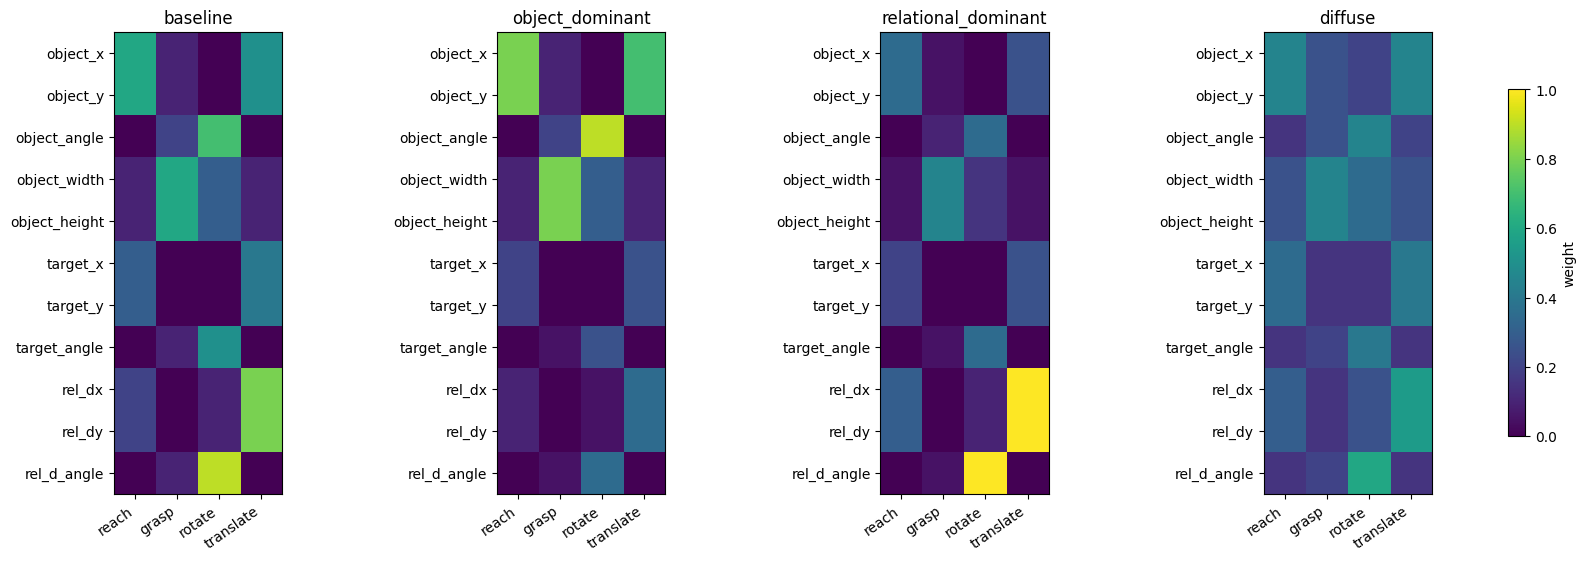

In [38]:
plot_affordance_matrices(VARIANTS)

## Run Experiments

- **success_rate** — Proportion of trials where the object was successfully inserted within position and angle tolerance
- **mean_timesteps** — Average number of simulation steps to complete the task (or timeout at 120 steps)
- **mean_pos_error** — Final Euclidean distance from goal (lower is better)
- **mean_angle_error** — Final angular difference from goal orientation (lower is better)
- **mean_efficiency** — Path efficiency ratio: optimal distance / actual path distance (0–1; 1 = perfectly direct)
- **mean_movement_onset** — How many steps elapse before the agent begins moving (reflects deliberation/information gathering)
- **mean_gaze_switches** — Total fixation switches between object and target (higher = more frequent attention shifts)

In [39]:
# Run all simulations: loop through stages, variants, tasks, and trials
# This populates 'rows' (trial-level data) and 'examples' (first trial per variant-stage-task)
rows, examples = run_variant_batch(STAGE_NAMES, TASK_NAMES, VARIANTS, N_TRIALS, SEED)

# Aggregate trial-level data into summary statistics (mean success rate, efficiency, etc.)
summary = summarise_rows(rows, VARIANTS, STAGE_NAMES, TASK_NAMES)

# Define which columns to display in the results table
# Includes metadata (variant, stage, task) and computed metrics
columns = [
    "variant", "stage", "task", "n_trials", "success_rate", "mean_timesteps",
    "mean_pos_error", "mean_angle_error", "mean_efficiency",
    "mean_movement_onset", "mean_gaze_switches",
]

# Display results as formatted HTML table for easy scanning and comparison
display(HTML(rows_to_html(summary, columns)))


variant,stage,task,n_trials,success_rate,mean_timesteps,mean_pos_error,mean_angle_error,mean_efficiency,mean_movement_onset,mean_gaze_switches
baseline,A,rotate_insert,25,0.360,100.920,1.813,0.821,0.381,1.920,9.080
baseline,B,rotate_insert,25,0.800,67.960,0.521,0.230,0.687,4.880,10.760
baseline,C,rotate_insert,25,1.000,41.600,0.018,0.092,0.983,8.040,10.640
baseline,D,rotate_insert,25,1.000,44.800,0.047,0.078,1.000,3.760,15.400
object_dominant,A,rotate_insert,25,0.360,101.400,1.912,0.811,0.377,1.920,9.080
object_dominant,B,rotate_insert,25,0.720,72.760,0.742,0.314,0.646,4.880,11.200
object_dominant,C,rotate_insert,25,1.000,42.440,0.021,0.092,0.976,8.040,10.720
object_dominant,D,rotate_insert,25,1.000,44.800,0.047,0.078,1.000,3.760,15.400
relational_dominant,A,rotate_insert,25,0.440,97.600,1.422,0.636,0.419,1.920,8.640
relational_dominant,B,rotate_insert,25,0.880,62.240,0.272,0.138,0.735,4.880,9.680


## Outcome Plots

**What to Look For:**

1. **Stage effects within a variant** — Do all developmental stages benefit similarly from a given affordance matrix, or does effectiveness depend on maturity?
   - **Converging bars** (all stages perform equally) → matrix is robust across development
   - **Diverging bars** (mature stages much higher) → matrix requires developmental readiness (mature gaze control, working memory, etc.)

2. **Variant rankings across stages** — Is there a consistent "best" matrix, or do rankings shuffle across stages?
   - **Consistent winner** → robust affordance structure
   - **Stage-dependent winner** → different strategies suit different developmental levels

3. **Absolute performance** — What are realistic performance levels? Stage A success rates of 20% with any variant might indicate the task is too hard for immature agents.

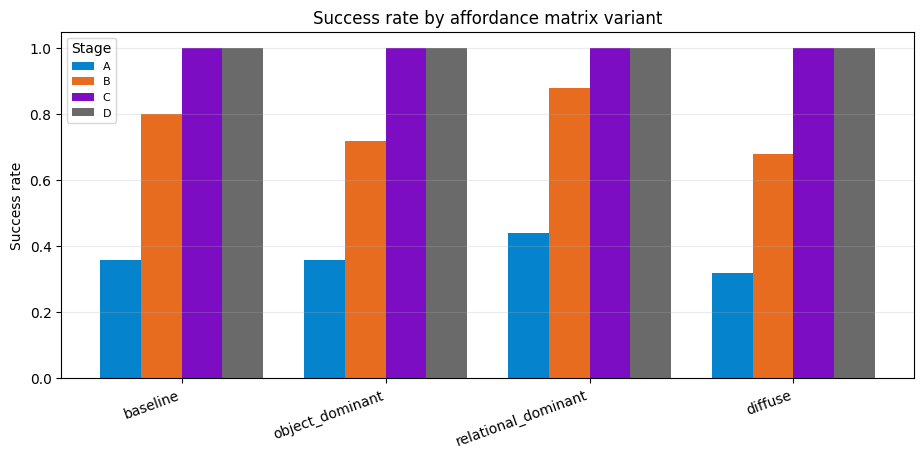

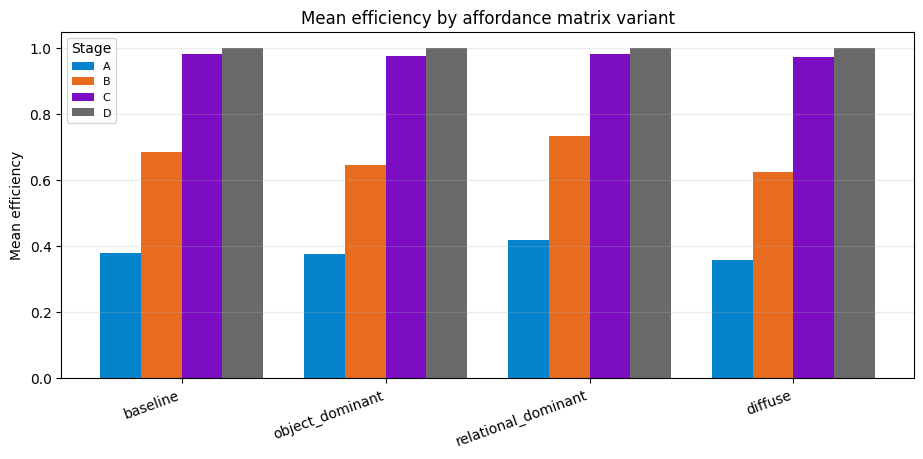

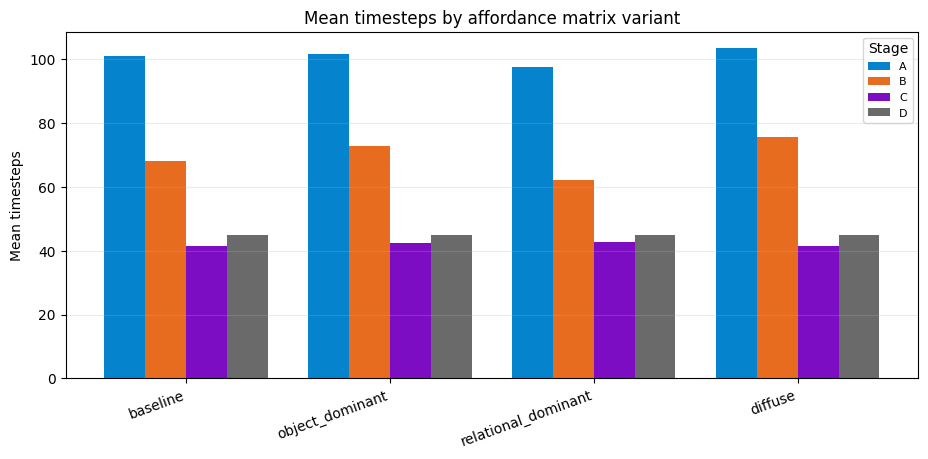

In [40]:
# Three key metrics reveal how affordance variants affect task performance:

# 1. Success rate: proportion of trials completed successfully
# Shows whether each variant-stage pair can solve the task at all
plot_metric_by_stage(summary, VARIANTS, STAGE_NAMES, "success_rate", "Success rate")

# 2. Efficiency: ratio of straight-line distance to actual path (0–1)
# Reveals path quality: straight = efficient, winding = inefficient (many corrections)
plot_metric_by_stage(summary, VARIANTS, STAGE_NAMES, "mean_efficiency", "Mean efficiency")

# 3. Timesteps: how many simulation steps to complete
# Lower = faster task execution; can indicate either good feedforward control
# or faster error-driven corrections depending on path shape
plot_metric_by_stage(summary, VARIANTS, STAGE_NAMES, "mean_timesteps", "Mean timesteps")


## Example Trajectories

These plots display the actual 2D path taken by the object during one representative trial (trial 0) for each affordance variant, all run with **stage C** developmental parameters.

- **Markers along lines** — Timesteps (closer dots = faster movement; sparse dots = slower)

### How to Interpret Path Shapes

| Path Pattern | Meaning |
|---|---|
| **Straight shot** | Variant produces feedforward control; agent commits confidently to goal |
| **Circuitous/curved** | Agent explores or corrects trajectory; less stable control or more reactive |
| **Loops/backtracking** | Agent overshoots or oscillates; poor damping or unstable error correction |
| **Slow approach** (many dots) | Task took many steps; might indicate hesitation or inefficient planning |
| **All paths converge** | All variants succeed but with different efficiencies |
| **Some paths miss goal** | Variant produces systematic errors; goal outside reachable space or tolerance |

### Comparing Variants
- **Subtle differences** (all nearly identical paths) → affordance structure doesn't strongly affect this stage's strategy
- **Major differences** (one takes shortcuts, another spirals) → affordance matrix substantially changes learned policy
- **Success vs. failure** (some reach goal, some drift away) → matrix enables or disables task completion

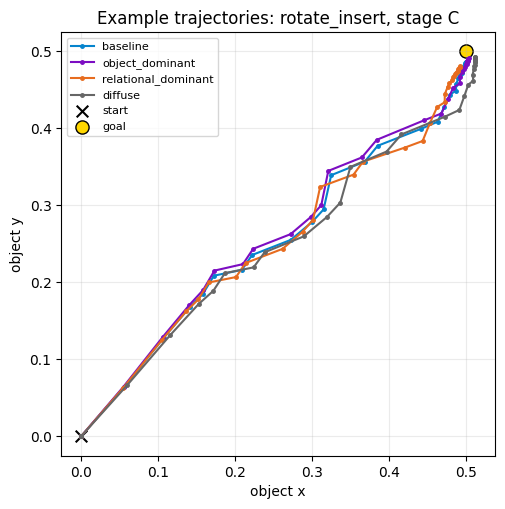

In [43]:
plot_example_trajectories(examples, VARIANTS, "C", "rotate_insert")